## Import Library

In [218]:
import pandas as pd
import numpy as np

# visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# model
from lightgbm import LGBMClassifier
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

# evaluasi
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

## Load Dataset

In [219]:
df = pd.read_csv("loan_data.csv")

# Hapus kolom ID yang tidak relevan
df = df.drop(columns=['Loan_ID'])

df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Eksplorasi Data & Missing Value

In [220]:
df.info()
print("\nMissing values:")
print(df.isnull().sum())
print("\nDistribusi target Loan_Status:")
print(df['Loan_Status'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    str    
 1   Married            611 non-null    str    
 2   Dependents         599 non-null    str    
 3   Education          614 non-null    str    
 4   Self_Employed      582 non-null    str    
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   600 non-null    float64
 9   Credit_History     564 non-null    float64
 10  Property_Area      614 non-null    str    
 11  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(7)
memory usage: 57.7 KB

Missing values:
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantInc

In [221]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


## Handling Missing Value

In [222]:
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())
    # df[col] = df[col].fillna(df[col].mean())

for col in df.select_dtypes(include='object').columns:
    if col != 'Loan_Status':
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values setelah handling:")
print(df.isnull().sum())

Missing values setelah handling:
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


/tmp/ipykernel_7148/2305750591.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


## Encoding Kategorikal

In [223]:
le = LabelEncoder()

cat_cols = [col for col in df.select_dtypes(include='object').columns if col != 'Loan_Status']
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Encode target dengan ubah Y/N ke 1/0
df['Loan_Status'] = (df['Loan_Status'] == 'Y').astype(int)

print("Distribusi target setelah encoding:")
print(df['Loan_Status'].value_counts())
print(f"\nJumlah kelas unik: {df['Loan_Status'].nunique()} → harus = 2")

Distribusi target setelah encoding:
Loan_Status
1    422
0    192
Name: count, dtype: int64

Jumlah kelas unik: 2 → harus = 2


/tmp/ipykernel_7148/2009677615.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = [col for col in df.select_dtypes(include='object').columns if col != 'Loan_Status']


## Boxplot

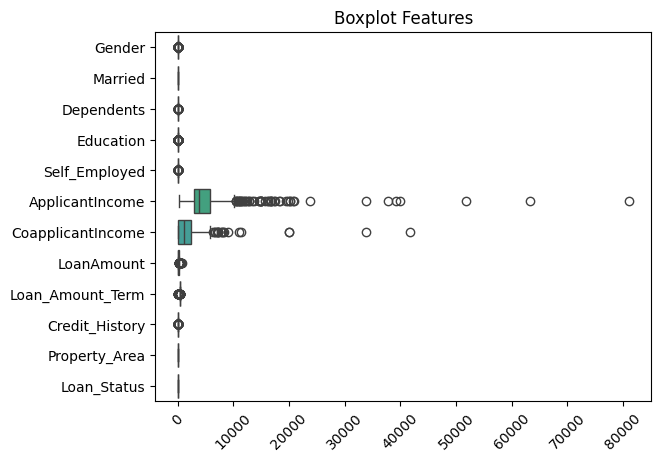

In [224]:
plt.figure()
sns.boxplot(data=df.select_dtypes(include=np.number), orient='h')
plt.xticks(rotation=45)
plt.title("Boxplot Features")
plt.show()

## Hapus Outlier

In [225]:
exclude_outlier_cols = ['Credit_History', 'Loan_Amount_Term', 'Loan_Status',
                        'Gender', 'Married', 'Dependents', 'Education',
                        'Self_Employed', 'Property_Area']

def remove_outlier(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

def replace_outlier(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    median = df[col].median()

    df[col] = np.where(df[col] < lower, median, df[col])
    df[col] = np.where(df[col] > upper, median, df[col])
    
    return df

# def replace_outlier_iterative(df, max_iter=500):
#     df = df.copy()
    
#     num_cols = [
#         col for col in df.select_dtypes(include=np.number).columns
#         if col not in exclude_outlier_cols and df[col].nunique() > 10
#     ]

#     df[num_cols] = df[num_cols].astype(float)

#     print("Kolom yang diproses:", num_cols)

#     for i in range(max_iter):
#         print(f"\nIterasi ke-{i+1}")
#         total_outliers = 0

#         for col in num_cols:
#             Q1 = df[col].quantile(0.25)
#             Q3 = df[col].quantile(0.75)
#             IQR = Q3 - Q1

#             lower = Q1 - 1.5 * IQR
#             upper = Q3 + 1.5 * IQR

#             median = df[col].median()

#             mask_lower = df[col] < lower
#             mask_upper = df[col] > upper

#             n_outliers = mask_lower.sum() + mask_upper.sum()
#             total_outliers += n_outliers

#             df.loc[mask_lower, col] = median
#             df.loc[mask_upper, col] = median

#         print(f"Total outlier diperbaiki: {total_outliers}")

#         if total_outliers == 0:
#             print("Tidak ada outlier lagi, stop iterasi.")
#             break

#     return df

# df = replace_outlier_iterative(df)

# for col in df.select_dtypes(include=np.number).columns:
#     if col not in exclude_outlier_cols:
#         df = remove_outlier(df, col)
        # df = replace_outlier(df, col)
        

print(f"Jumlah data setelah outlier removal: {len(df)}")
print("Distribusi target setelah outlier removal:")
print(df['Loan_Status'].value_counts())

Jumlah data setelah outlier removal: 614
Distribusi target setelah outlier removal:
Loan_Status
1    422
0    192
Name: count, dtype: int64


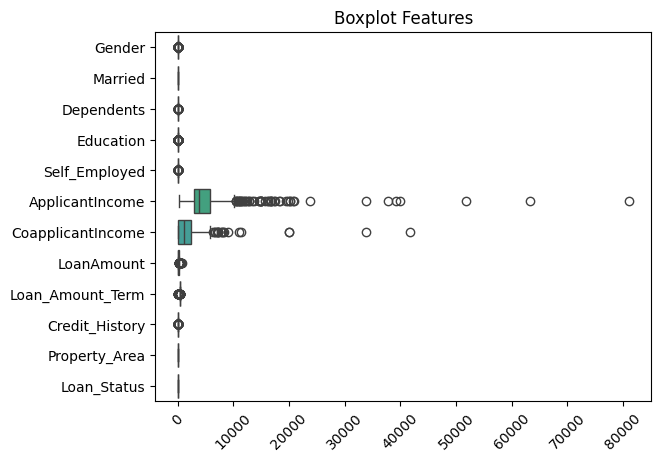

In [226]:
sns.boxplot(data=df.select_dtypes(include=np.number), orient='h')
plt.xticks(rotation=45)
plt.title("Boxplot Features")
plt.show()

## Feature Construction

In [227]:
# Membuat Fitur Baru
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']

df['LoanAmount_Income_Ratio'] = df['LoanAmount'] / (df['Total_Income'] + 1)

print("Kolom setelah feature construction:")
print(df.columns.tolist())

Kolom setelah feature construction:
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status', 'Total_Income', 'LoanAmount_Income_Ratio']


## Split Data

In [228]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print("Distribusi target train:", y_train.value_counts().to_dict())
print("Distribusi target test:", y_test.value_counts().to_dict())

Train size: 491, Test size: 123
Distribusi target train: {1: 337, 0: 154}
Distribusi target test: {1: 85, 0: 38}


### Aktifkan Salah 1 Saja Metode Scaling

## Z Score

In [ ]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)  
# X_test = scaler.transform(X_test)        

## Min Max Scaling

In [ ]:
# from sklearn.preprocessing import MinMaxScaler

# scaler = MinMaxScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

## Decimal Scaling

In [ ]:
# import numpy as np

# def decimal_scaling(X):
#     X_scaled = X.copy()
    
#     for col in X.columns:
#         max_val = X[col].abs().max()
#         j = len(str(int(max_val)))  # jumlah digit
        
#         X_scaled[col] = X[col] / (10 ** j)
    
#     return X_scaled

# # pakai
# X_train_scaled = decimal_scaling(X_train)
# X_test_scaled = decimal_scaling(X_test)

## Log Scaling

In [232]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

for col in X_train.columns:
    X_train_scaled[col] = np.log1p(X_train[col])
    X_test_scaled[col] = np.log1p(X_test[col])

## Model LightGBM

In [233]:
model = LGBMClassifier(random_state=42, verbose=-1)

# model = AdaBoostRegressor(
#     estimator=DecisionTreeRegressor(max_depth=3),
#     n_estimators=100,
#     learning_rate=0.1,
#     random_state=42
# )

# model.fit(X_train, y_train)
model.fit(X_train_scaled, y_train)

print("Model berhasil dilatih.")

Model berhasil dilatih.


## Evaluasi Model

In [234]:
y_pred = model.predict(X_test)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Ditolak (0)', 'Disetujui (1)']))

# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# y_pred = model.predict(X_test)

# mae = mean_absolute_error(y_test, y_pred)
# mse = mean_squared_error(y_test, y_pred)
# rmse = np.sqrt(mse)
# r2 = r2_score(y_test, y_pred)

# print(f"MAE  : {mae:.4f}")
# print(f"MSE  : {mse:.4f}")
# print(f"RMSE : {rmse:.4f}")
# print(f"R2   : {r2:.4f}")

Accuracy : 0.8211
Precision: 0.9200
Recall   : 0.8118
F1 Score : 0.8625

Classification Report:
               precision    recall  f1-score   support

  Ditolak (0)       0.67      0.84      0.74        38
Disetujui (1)       0.92      0.81      0.86        85

     accuracy                           0.82       123
    macro avg       0.79      0.83      0.80       123
 weighted avg       0.84      0.82      0.83       123



## HeatMap

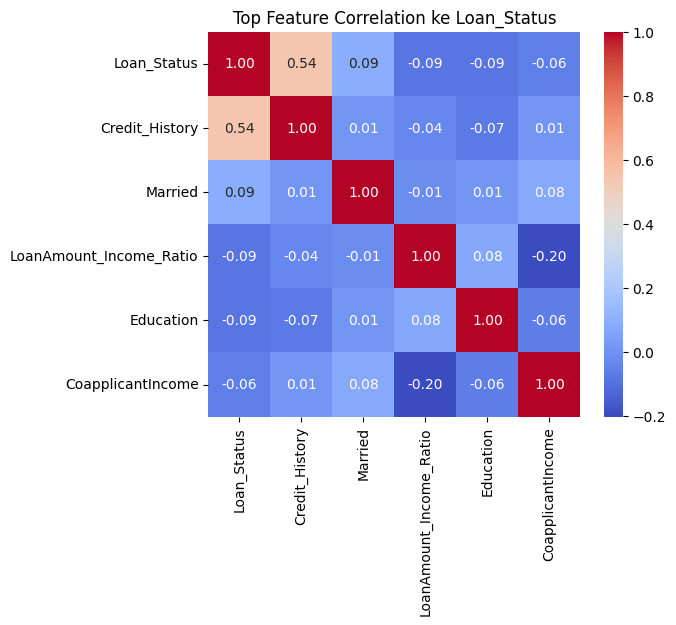

In [235]:
# plt.figure()
# sns.heatmap(df.corr(numeric_only=True), annot=True)
# plt.title("Correlation Heatmap")
# plt.show()

corr = df.corr(numeric_only=True)

# ambil top fitur terhadap target
top_features = corr['Loan_Status'].abs().sort_values(ascending=False).head(6).index

corr_top = df[top_features].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_top, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Top Feature Correlation ke Loan_Status")
plt.show()

